In [517]:
# https://www.kaggle.com/datasets/vishakhdapat/customer-segmentation-clustering

import kagglehub

# Download latest version
path = kagglehub.dataset_download("vishakhdapat/customer-segmentation-clustering")

print("Path to dataset files:", path)

Path to dataset files: /home/rpsingh/.cache/kagglehub/datasets/vishakhdapat/customer-segmentation-clustering/versions/1


In [518]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [519]:
df = pd.read_csv('/home/rpsingh/.cache/kagglehub/datasets/vishakhdapat/customer-segmentation-clustering/versions/1/customer_segmentation.csv')

In [520]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [521]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [522]:
df.isna().sum().sum()

np.int64(24)

In [523]:
df.dropna(inplace=True)

In [524]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [525]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [526]:
df['Age'] = 2026 - df['Year_Birth']

In [527]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [528]:
spend_colums = ['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds',]
df['Total_Spending'] = df[spend_colums].sum(axis=1)

In [529]:
df['Customer_Since'] = (pd.Timestamp('today')-df['Dt_Customer']).dt.days

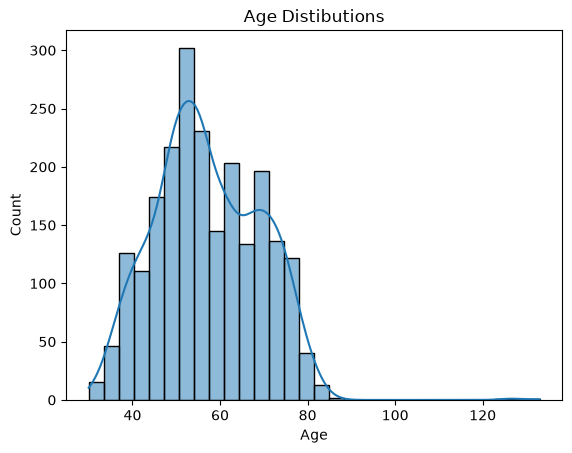

In [530]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distibutions")
plt.show()

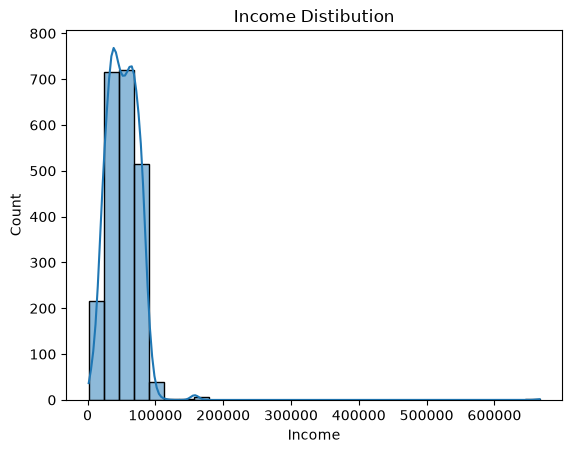

In [531]:
sns.histplot(df['Income'], bins=30, kde=True)
plt.title("Income Distibution")
plt.show()

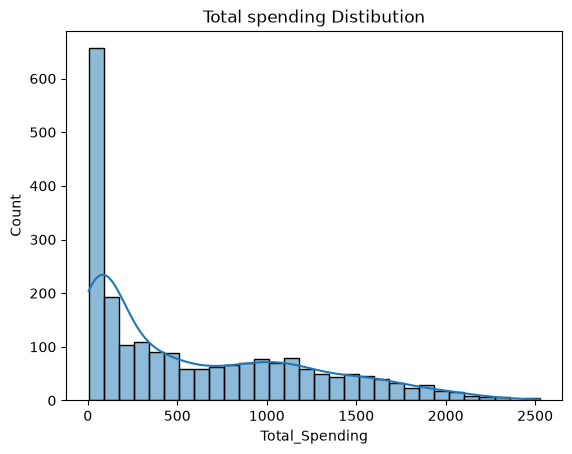

In [532]:
sns.histplot(df['Total_Spending'], bins=30, kde=True)
plt.title("Total spending Distibution")
plt.show()

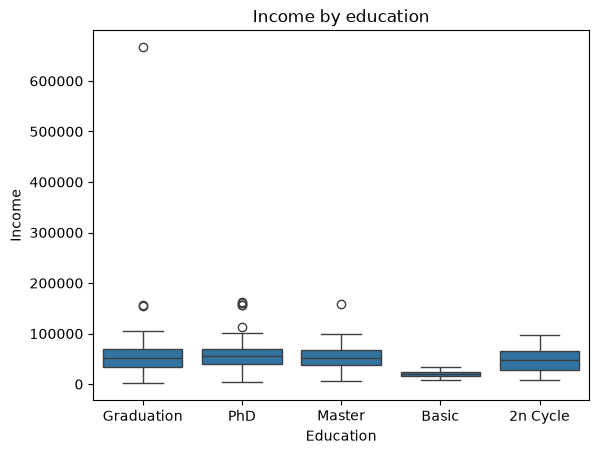

In [533]:
sns.boxplot(data=df, x='Education', y='Income')
plt.title("Income by education")
plt.show()

In [534]:
df.shape

(2216, 33)

In [535]:
df[df['Education']=='Graduation'][['Income']].describe()

,Income
count,1116.000000
mean,52720.373656
std,28177.192681
min,1730.000000
25%,34834.500000
50%,52028.500000
75%,69930.500000
max,666666.000000


In [536]:
df[df['Income']>110000][['ID', 'Income']]

,ID,Income
164,8475,157243.0
617,1503,162397.0
655,5555,153924.0
687,1501,160803.0
1300,5336,157733.0
1653,4931,157146.0
1898,4619,113734.0
2132,11181,156924.0
2233,9432,666666.0


In [537]:
print(df.shape, df[df['Income']<110000].shape)

(2216, 33) (2207, 33)


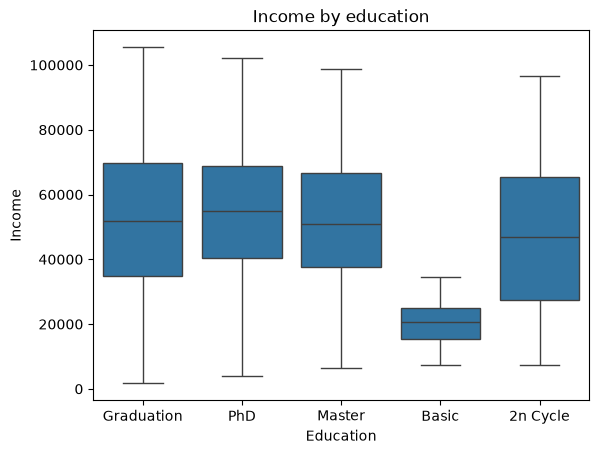

In [538]:
sns.boxplot(data=df[df['Income']<110000], x='Education', y='Income')
plt.title("Income by education")
plt.show()

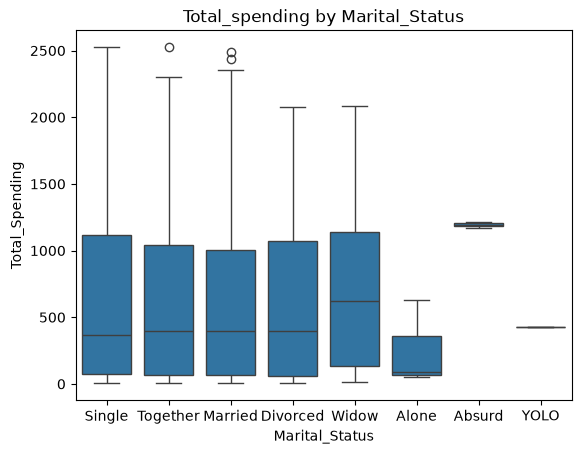

In [539]:
sns.boxplot(data=df, x='Marital_Status', y='Total_Spending')
plt.title("Total_spending by Marital_Status")
plt.show()

In [540]:
df[df['Marital_Status'].isin(['Absurd', 'YOLO'])]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since
2093,7734,1993,Graduation,Absurd,79244.0,0,0,2012-12-19,58,471,...,1,0,0,3,11,1,33,0,1216,4996
2134,4369,1957,Master,Absurd,65487.0,0,0,2014-01-10,48,240,...,0,0,0,3,11,0,69,0,1169,4609
2177,492,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,0,0,0,3,11,0,53,1,424,5058
2202,11133,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,0,0,0,3,11,1,53,1,424,5058


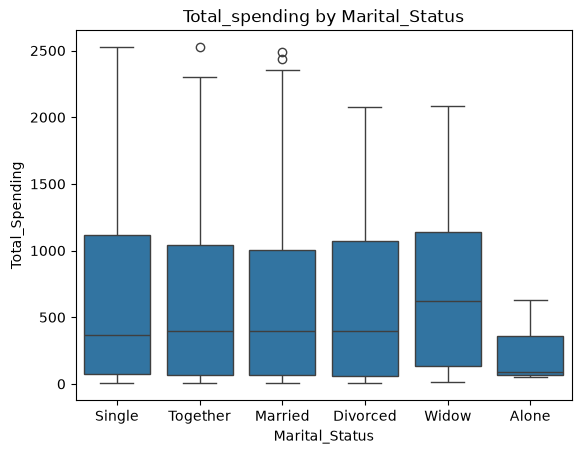

In [541]:
sns.boxplot(data=df[df['Marital_Status'].isin(['Absurd', 'YOLO'])==False], x='Marital_Status', y='Total_Spending')
plt.title("Total_spending by Marital_Status")
plt.show()

In [ ]:
df_filtered = df[df['Age'] < 100]
bins = list(range(0, 101, 10))
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]


plt.figure(figsize=(10, 6))

# 2. Pass the filtered DataFrame and generate bins directly from it
sns.boxplot(
    data=df_filtered, 
    x=pd.cut(df_filtered['Age'], bins=bins, labels=labels, right=False), 
    y='Total_Spending'
)

plt.title("Total Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [543]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='str')

In [544]:
mask = (
    (df['Income']<110000) & (df['Marital_Status'].isin(['Absurd', 'YOLO'])==False)
)
print(f'orignal df size: {df.shape}', end=', ')
df = df[mask]
print(f'New Df size: {df.shape}')

feature_columns = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']
# feature_columns = ['Age', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']
# feature_columns = ['Age', 'Total_Spending', 'Recency']
X = df[feature_columns].copy()
X.shape

orignal df size: (2216, 33), New Df size: (2203, 33)


(2203, 7)

In [545]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [546]:
X_scaled = scaler.fit_transform(X)

In [547]:
X_scaled

array([[ 0.98587038,  0.31666968,  1.6774374 , ..., -0.56167975,
         0.68989912,  0.30878713],
       [ 1.23633618, -0.25366272, -0.96239225, ..., -1.17851947,
        -0.13993859, -0.38281316],
       [ 0.31796158,  0.96829161,  0.28115014, ...,  1.28883942,
        -0.55485744, -0.79777334],
       ...,
       [-1.01785602,  0.26071965,  1.0531758 , ...,  2.21409901,
         0.27498027,  1.44992762],
       [ 1.06935898,  0.85378024,  0.39238825, ...,  1.28883942,
        -0.96977629, -1.42021361],
       [ 1.23633618,  0.0618722 , -0.72165307, ..., -0.56167975,
         0.68989912, -0.31365314]], shape=(2203, 7))

In [548]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

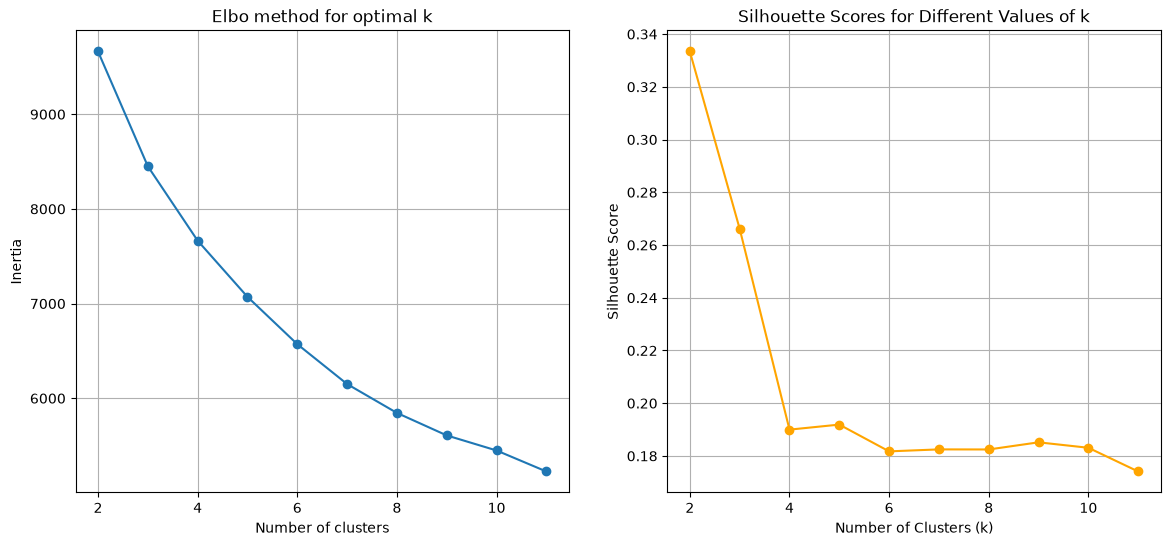

In [549]:
wcss = []
silhoutte_scores = []
for i in range(2, 12):
    km = KMeans(n_clusters=i, random_state=42, max_iter=1000)
    cluster_labels = km.fit_predict(X_scaled)
    silhoutte_scores.append(silhouette_score(X_scaled, cluster_labels))
    wcss.append(km.inertia_)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(2, 12), wcss, marker='o')
plt.title('Elbo method for optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(2, 12), silhoutte_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


In [550]:
kms = KMeans(n_clusters=3, random_state=42, max_iter=1000)
df['Cluster'] = kms.fit_predict(X_scaled)

In [551]:
cluster_summary = df.groupby('Cluster')[feature_columns].mean()
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,54.335597,34113.120272,102.961203,2.120272,3.212415,6.509214,49.516974
1,57.866667,75071.075000,1274.831667,4.580000,8.581667,2.491667,50.701667
2,61.631119,58458.867133,813.671329,7.110140,7.627622,6.209790,46.554196


In [552]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]

In [553]:
df.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,69,0,1617,5102,2,1.141597,0.198534
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,72,2,27,4552,0,-1.338114,0.195031


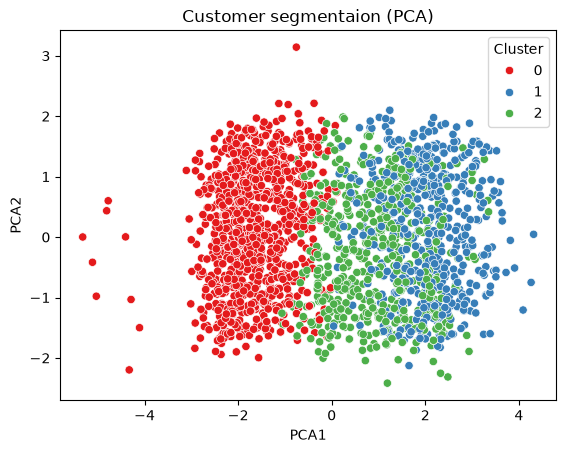

In [554]:
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1')
plt.title("Customer segmentaion (PCA)")
plt.show()

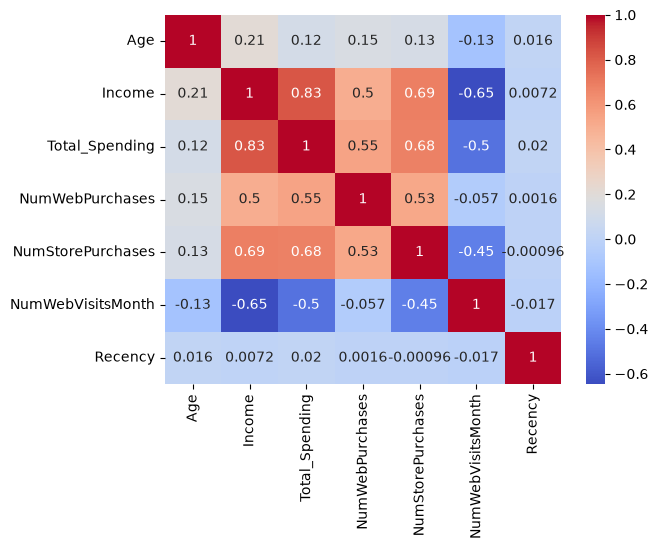

In [555]:
sns.heatmap(data=X.corr(), annot=True, cmap='coolwarm')
plt.show()

# 3D Plot

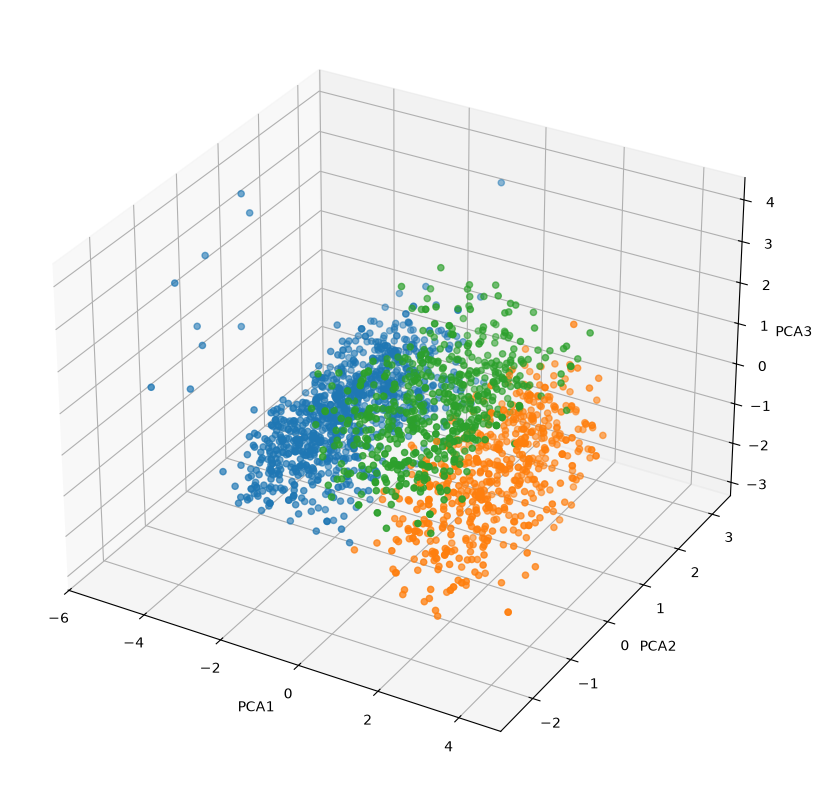

In [556]:
ndf = df.copy()
pca = PCA(n_components=3)
pca_data = pca.fit_transform(X_scaled)
ndf['PCA1'], ndf['PCA2'], ndf['PCA3'] = pca_data[:, 0], pca_data[:, 1], pca_data[:, 2]

cluster_colors = {0: '#1f77b4',  # Blue
                  1: '#ff7f0e',  # Orange
                  2: '#2ca02c',  # Green
                  3: '#d62728',
                  4: "#de10d3",
                  5: "#5c181c",
                }  # Red
colors = ndf['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(ndf['PCA1'], ndf['PCA2'], ndf['PCA3'], marker='o', c=colors)
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
plt.show()


In [557]:
ndf.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,Cluster,PCA1,PCA2,PCA3
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,11,1,69,0,1617,5102,2,1.141597,0.198534,1.64394
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,11,0,72,2,27,4552,0,-1.338114,0.195031,0.16624


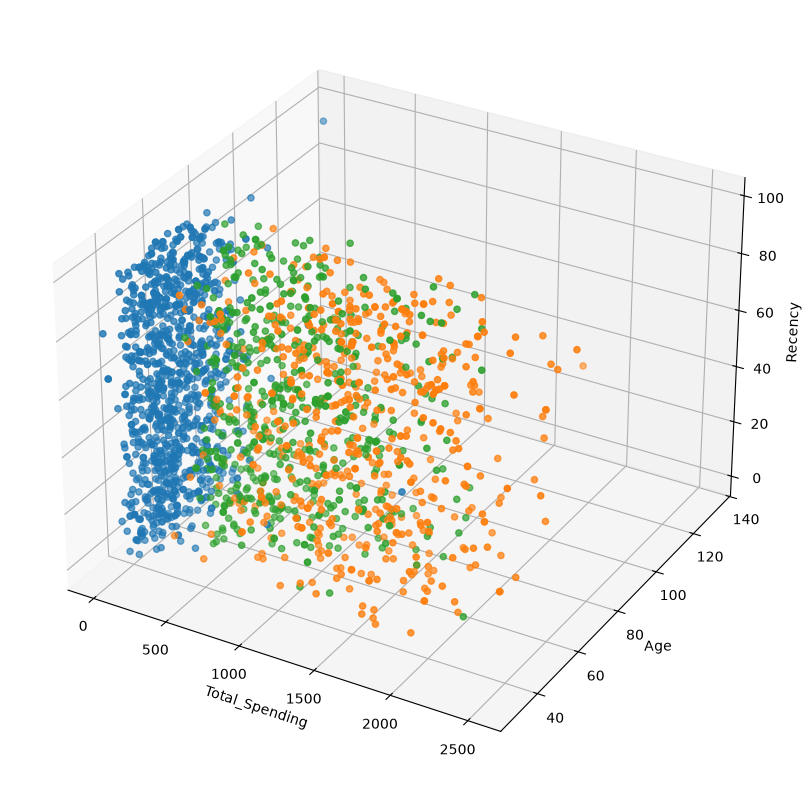

In [558]:
ndf = df.copy()
# pca = PCA(n_components=3)
# pca_data = pca.fit_transform(X_scaled)
# ndf['PCA1'], ndf['PCA2'], ndf['PCA3'] = pca_data[:, 0], pca_data[:, 1], pca_data[:, 2]

cluster_colors = {0: '#1f77b4',  # Blue
                  1: '#ff7f0e',  # Orange
                  2: '#2ca02c',  # Green
                  3: '#d62728',
                  4: "#de10d3",
                  5: "#5c181c",
                }  # Red
colors = ndf['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(ndf['Total_Spending'], ndf['Age'], ndf['Recency'], marker='o', c=colors)
ax.set_xlabel('Total_Spending')
ax.set_ylabel('Age')
ax.set_zlabel('Recency')
plt.show()

In [559]:
X[X['Age']>100]

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
192,126,36640.0,65,2,2,5,99
239,133,60182.0,22,1,2,4,23
339,127,83532.0,1853,4,4,1,36
